In [1]:
import pandas as pd
import glob
import os

base_dir = r"D:\BLA_ChR_resp"

folders = [
    os.path.join(base_dir, "RI2_day1_boris_post"),
    os.path.join(base_dir, "RI2_day2_boris_post")
]

files = []
for f in folders:
    files.extend(glob.glob(os.path.join(f, "*.csv")))

# 🚫 Exclude social-agent scoring
files = [f for f in files if not f.endswith("_sa.csv")]

len(files)

46

In [2]:
for f in files:
    print(f)

D:\BLA_ChR_resp\RI2_day1_boris_post\1_1_RI2_f2_h_off_20260119_134817.1.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\1_2_RI2_f1_a_on_20260119_170144.1.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\1_3_RI2_f2_f_on_20260119_152733.1.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\2_1_RI2_f1_a_off_VT_BORIS_day1post.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\2_2_RI2_f2_3_on_20260119_144717.1.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\2_3_RI2_f1_d_off_VT_BORIS_day1post.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\3_1_RI2_f2_f_off_20260119_164023.1.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\3_2_RI2_f1_b_on_20260119_181446.1.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\3_3_RI2_f2_e_off_VT_BORIS_day1post.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\4_2_RI2_f2_f_on_VT_BORIS_day1post.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\4_3_RI2_f1_a_off_20260119_172948.1.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\5_1_RI2_m2_p_off_20260119_143035.1.csv
D:\BLA_ChR_resp\RI2_day1_boris_post\5_2_RI2_m1_k_on_20260119_175411.1.csv
D:\BLA_ChR_resp\RI2_day1_boris_

In [3]:
def load_boris_for_inspection(csv_path):
    df = pd.read_csv(csv_path)

    # --- Standardize timing column names ---
    df = df.rename(columns={
        "Start (s)": "Start",
        "Stop (s)": "Stop",
        "Duration (s)": "Duration"
    })

    # --- Keep only columns needed to LOOK at behavior ---
    keep_cols = [
        "Behavior",
        "Behavior type",
        "Subject",              # BORIS role: subject / agent
        "Start",
        "Stop",
        "Duration",
        "FPS (frame/s)",
        "Image index start",
        "Image index stop",
        "Media file name"
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()

    # --- Light cleaning ---
    df["Behavior"] = df["Behavior"].astype(str).str.strip().str.lower()
    df["Subject"] = df["Subject"].astype(str).str.strip().str.lower()

    # ============================
    # ADD METADATA FROM FILENAME
    # ============================
    fname = os.path.basename(csv_path)
    parts = fname.replace(".csv", "").split("_")

    # Subject ID = cage_mouse (e.g. 1_2)
    cage = parts[0]
    mouse = parts[1]
    subject_id = f"{cage}_{mouse}"

    # Laser condition
    laser = "ON" if "on" in parts else "OFF"

    df["SubjectID"] = subject_id
    df["Laser"] = laser

    return df

In [4]:
dfs = []
for f in files:
    df = load_boris_for_inspection(f)
    df["File"] = os.path.basename(f)
    dfs.append(df)

boris_df = pd.concat(dfs, ignore_index=True)

In [5]:
boris_df = boris_df.copy()

# Extract cage number from SubjectID (e.g. "3_2" → 3)
boris_df["Cage"] = boris_df["SubjectID"].str.split("_").str[0].astype(int)

# Assign group
boris_df["Group"] = boris_df["Cage"].apply(
    lambda x: "GFP" if x % 2 == 0 else "ChR-YFP")

In [6]:
bout_counts = (
    boris_df
    .groupby(["SubjectID", "Group", "Laser", "Behavior"], as_index=False)
    .size()
    .rename(columns={"size": "BoutCount"})
)

In [7]:
paired = (
    bout_counts
    .groupby(["SubjectID", "Group", "Behavior"])["Laser"]
    .nunique()
    .reset_index()
)

paired = paired[paired["Laser"] == 2]   # must have ON + OFF

bout_counts_paired = bout_counts.merge(
    paired[["SubjectID", "Group", "Behavior"]],
    on=["SubjectID", "Group", "Behavior"],
    how="inner"
)

In [8]:
investigation_behaviors = [
    "facial sniffing",
    "body sniffing",
    "anogenital sniffing"
]

In [9]:
invest_df = boris_df[
    boris_df["Behavior"].isin(investigation_behaviors)
].copy()

invest_time = (
    invest_df
    .groupby(["SubjectID", "Group", "Laser"], as_index=False)
    .agg(InvestigationTime=("Duration", "sum"))
)


In [10]:
invest_time.head()
invest_time.groupby(["Group", "Laser"]).size()


Group    Laser
ChR-YFP  OFF      12
         ON       10
GFP      OFF       9
         ON        8
dtype: int64

In [11]:
file_presence = (
    boris_df
    .groupby(["SubjectID", "Group", "Laser"])["File"]
    .nunique()
    .reset_index(name="N_files")
)

file_presence[file_presence["SubjectID"].isin(["5_3", "6_3", "7_3"])]

,SubjectID,Group,Laser,N_files
26,5_3,ChR-YFP,ON,1
29,6_3,GFP,ON,1
34,7_3,ChR-YFP,OFF,1


In [12]:
file_table = (
    boris_df
    .groupby(["SubjectID", "Group", "Laser"])["File"]
    .nunique()
    .reset_index(name="N_files")
)

file_table.sort_values(["Group", "SubjectID", "Laser"])

,SubjectID,Group,Laser,N_files
0,1_1,ChR-YFP,OFF,1
1,1_1,ChR-YFP,ON,1
2,1_2,ChR-YFP,OFF,1
3,1_2,ChR-YFP,ON,1
4,1_3,ChR-YFP,OFF,1
5,1_3,ChR-YFP,ON,1
12,3_1,ChR-YFP,OFF,1
13,3_1,ChR-YFP,ON,1
14,3_2,ChR-YFP,OFF,1
15,3_2,ChR-YFP,ON,1


In [13]:
exclude_subjects = ["5_3", "6_3", "7_3"]

invest_time_paired = invest_time[
    ~invest_time["SubjectID"].isin(exclude_subjects)
].copy()

In [14]:
paired_subjects = (
    invest_time
    .groupby(["SubjectID", "Group"])["Laser"]
    .nunique()
    .reset_index()
    .query("Laser == 2")
)

invest_time_paired = invest_time.merge(
    paired_subjects[["SubjectID", "Group"]],
    on=["SubjectID", "Group"],
    how="inner"
)

In [15]:
invest_time_paired.groupby(["Group", "Laser"]).size()

Group    Laser
ChR-YFP  OFF      9
         ON       9
GFP      OFF      8
         ON       8
dtype: int64

In [16]:
invest_plot = invest_time_paired.copy()

C:\Users\sjs93\AppData\Local\Temp\ipykernel_31676\3371639298.py:33: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


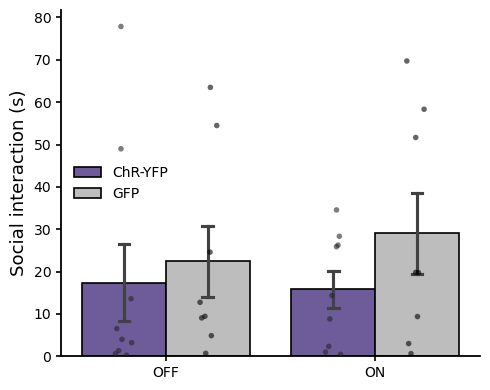

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Orders ---
laser_order = ["OFF", "ON"]
group_order = ["ChR-YFP", "GFP"]

# --- Colors ---
group_palette = {
    "ChR-YFP": "#6A51A3",  # purple
    "GFP": "#BDBDBD"       # gray
}

plt.figure(figsize=(5, 4))

# --- Bar plot (mean ± SEM) ---
sns.barplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    hue="Group",
    order=laser_order,
    hue_order=group_order,
    errorbar="se",
    palette=group_palette,
    edgecolor="black",
    linewidth=1.2,
    capsize=0.1
)

# --- Overlay jittered individual points ---
sns.stripplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    hue="Group",
    order=laser_order,
    hue_order=group_order,
    dodge=True,
    color="black",
    size=4,
    alpha=0.6
)

# --- Clean up double legend (stripplot adds another) ---
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], frameon=False)

# --- Style like paper ---
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.3)
ax.spines["bottom"].set_linewidth(1.3)

ax.set_ylabel("Social interaction (s)", fontsize=13)
ax.set_xlabel("")
ax.tick_params(width=1.2)

plt.tight_layout()
plt.show()


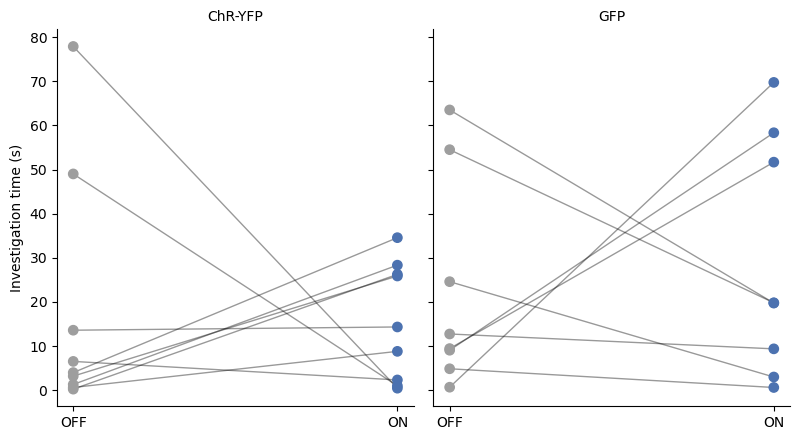

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.FacetGrid(
    invest_plot,
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def paired_lines(data, **kwargs):
    ax = plt.gca()
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == {"ON", "OFF"}:
            df_sub = df_sub.sort_values("Laser")  # OFF -> ON
            ax.plot(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1
            )
            ax.scatter(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                c=[palette_laser[l] for l in df_sub["Laser"]],
                s=45,
                zorder=3
            )

g.map_dataframe(paired_lines)

g.set_axis_labels("", "Investigation time (s)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()


In [19]:
(
    boris_df
    .assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    )
    .pivot_table(
        index=["Behavior", "Group"],
        columns="Laser",
        values="File",     # any column works, we just count rows
        aggfunc="count",
        fill_value=0
    )
    .sort_values(["Group"], ascending=True)
)

,Laser,OFF,ON
Behavior,Group,,
anogenital sniffing,ChR-YFP,14,18
body sniffing,ChR-YFP,40,46
digging,ChR-YFP,9,2
facial sniffing,ChR-YFP,66,66
self-grooming,ChR-YFP,33,29
anogenital sniffing,GFP,17,24
body sniffing,GFP,40,55
digging,GFP,4,7
facial sniffing,GFP,73,68


C:\Users\sjs93\AppData\Local\Temp\ipykernel_31676\3515223227.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31676\3515223227.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


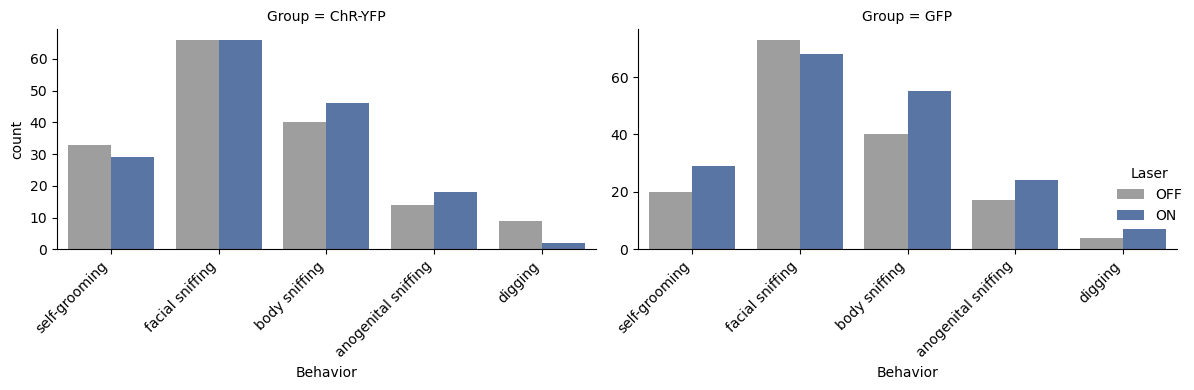

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.catplot(
    data=boris_df.assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    ),
    x="Behavior",
    hue="Laser",
    col="Group",
    kind="count",
    palette=palette_laser,
    height=4,
    aspect=1.4,
    sharey=False
)

# 🔄 Rotate x-axis labels to 45°
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [21]:

(
    boris_df
    .assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    )
    .groupby(["Group", "Laser", "Behavior"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Group", "Laser", "Count"], ascending=[True, True, False])
)

,Group,Laser,Behavior,Count
3,ChR-YFP,OFF,facial sniffing,66
1,ChR-YFP,OFF,body sniffing,40
4,ChR-YFP,OFF,self-grooming,33
0,ChR-YFP,OFF,anogenital sniffing,14
2,ChR-YFP,OFF,digging,9
8,ChR-YFP,ON,facial sniffing,66
6,ChR-YFP,ON,body sniffing,46
9,ChR-YFP,ON,self-grooming,29
5,ChR-YFP,ON,anogenital sniffing,18
7,ChR-YFP,ON,digging,2


In [22]:
(
    boris_df["Behavior"]
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
)


Behavior
facial sniffing        273
body sniffing          181
self-grooming          111
anogenital sniffing     73
digging                 22
Name: count, dtype: int64

In [23]:
exclude_behaviors = ["self-grooming", "digging"]

investigation_behaviors = (
    boris_df["Behavior"]
    .astype(str)
    .str.lower()
    .str.strip()
    .unique()
)

investigation_behaviors = [
    b for b in investigation_behaviors
    if b not in exclude_behaviors
]

investigation_behaviors

['facial sniffing', 'body sniffing', 'anogenital sniffing']

In [24]:
invest_time = (
    boris_df
    .assign(Behavior=lambda df: df["Behavior"].str.lower().str.strip())
    .query("Behavior in @investigation_behaviors")
    .groupby(["SubjectID", "Group", "Laser"], as_index=False)
    .agg(InvestigationTime=("Duration", "sum"))
)


In [25]:
paired_subjects = (
    invest_time
    .groupby(["SubjectID", "Group"])["Laser"]
    .nunique()
    .reset_index()
    .query("Laser == 2")
)

invest_plot = invest_time.merge(
    paired_subjects[["SubjectID", "Group"]],
    on=["SubjectID", "Group"],
    how="inner"
)

In [26]:
invest_plot.groupby(["Group", "Laser"]).size()

Group    Laser
ChR-YFP  OFF      9
         ON       9
GFP      OFF      8
         ON       8
dtype: int64

In [27]:
invest_plot.columns.tolist()

['SubjectID', 'Group', 'Laser', 'InvestigationTime']

In [28]:
def subject_to_sex(subject_id):
    cage = int(subject_id.split("_")[0])
    return "Female" if cage <= 4 else "Male"

invest_plot = invest_plot.copy()
invest_plot["SubjSex"] = invest_plot["SubjectID"].apply(subject_to_sex)

In [29]:
invest_plot[["SubjectID", "SubjSex"]].drop_duplicates().sort_values("SubjectID")

,SubjectID,SubjSex
0,1_1,Female
2,1_2,Female
4,2_1,Female
6,2_2,Female
8,2_3,Female
10,3_1,Female
12,3_2,Female
14,3_3,Female
16,4_2,Female
18,4_3,Female


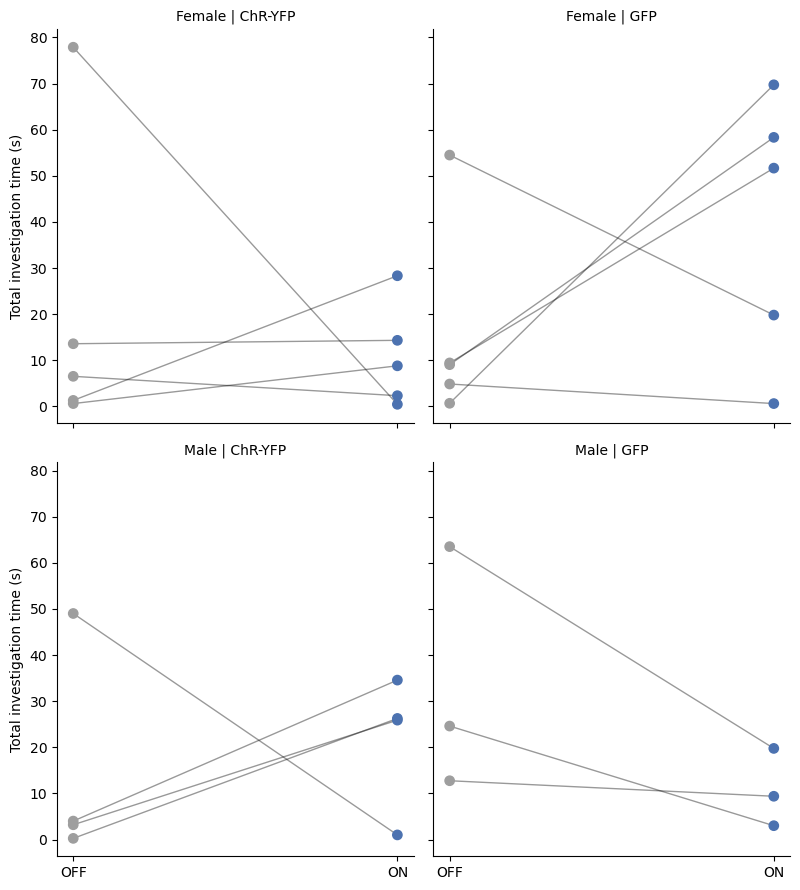

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def paired_lines(data, **kwargs):
    ax = plt.gca()
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == {"OFF", "ON"}:
            df_sub = df_sub.sort_values("Laser")
            ax.plot(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1
            )
            ax.scatter(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                c=[palette_laser[l] for l in df_sub["Laser"]],
                s=45,
                zorder=3
            )

g.map_dataframe(paired_lines)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles("{row_name} | {col_name}")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import sem

sns.set_style("white")

laser_order = ["OFF", "ON"]

# --- Sex-specific color palettes ---
sex_palette = {
    "Female": {
        "OFF": "#F4A6C1",   # light pink
        "ON":  "#D81B60"    # darker pink
    },
    "Male": {
        "OFF": "#A6C8E0",   # light blue
        "ON":  "#1F77B4"    # darker blue
    }
}

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def bar_with_pairs(data, **kwargs):
    ax = plt.gca()

    sex = data["SubjSex"].iloc[0]  # get sex for this panel

    means = []
    errors = []

    for laser in laser_order:
        vals = data[data["Laser"] == laser]["InvestigationTime"]
        means.append(vals.mean())
        errors.append(sem(vals))

    x = np.arange(len(laser_order))

    # --- Bars colored by sex ---
    ax.bar(
        x,
        means,
        yerr=errors,
        capsize=4,
        color=[sex_palette[sex][l] for l in laser_order],
        edgecolor="black",
        linewidth=1.2,
        width=0.6,
        zorder=1
    )

    # --- Paired lines ---
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == set(laser_order):
            df_sub = df_sub.set_index("Laser").loc[laser_order]

            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.35,
                linewidth=1,
                zorder=3
            )

            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                color="black",
                s=30,
                zorder=4
            )

    # --- Clean styling ---
    ax.set_xticks(x)
    ax.set_xticklabels(laser_order)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.tick_params(width=1.2)

g.map_dataframe(bar_with_pairs)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()